# 1.2 Sampled RPC Calibration: State, Access Lists, And Authorizations

Notebook 1.1 is Xatu-only, so it cannot see exact account-existence/delegation state, transaction access lists, or EIP-7702 authorization tuples. This notebook calibrates those missing pieces from a deterministic sampled block panel.

This is the **light** RPC path. Per sampled block it fetches:

1. `debug_traceBlockByNumber` with `prestateTracer`, `diffMode=True`
2. `eth_getBlockReceipts`
3. `eth_getBlockByNumber(..., true)`

It intentionally does **not** fetch the full non-diff prestate trace for storage reads and does **not** build BALs. BAL size calibration and regression live in notebook 1.3.


## Setup


In [1]:
import os
import time
from pathlib import Path
import sys

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sim.rpc_calibration import calibrate_blocks, sample_blocks_per_day

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

ETHNODEOPS_API_KEY = os.environ.get("ETHNODEOPS_API_KEY") or os.environ.get("hoodi_api_key")
ETHNODEOPS_RPC = os.environ.get("ETHNODEOPS_RPC", "https://erigon.mainnet.rpc.ethnodeops.xyz")
ALCHEMY_RPC = os.environ.get("ALCHEMY_RPC")

if ETHNODEOPS_API_KEY:
    RPC_URL = ETHNODEOPS_RPC
    RPC_HEADERS = {"X-API-Key": ETHNODEOPS_API_KEY}
    RPC_PROVIDER_LABEL = "ethnodeops_erigon_mainnet"
elif ALCHEMY_RPC:
    RPC_URL = ALCHEMY_RPC
    RPC_HEADERS = None
    RPC_PROVIDER_LABEL = "alchemy_mainnet"
else:
    raise RuntimeError("Missing ETHNODEOPS_API_KEY, hoodi_api_key, or ALCHEMY_RPC in .env")

print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)
print("rpc_provider", RPC_PROVIDER_LABEL)


raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]
rpc_provider ethnodeops_erigon_mainnet


## Parameters

`RUN_BLOCKS_PER_DAY = 50` gives 6,000 blocks across the Feb-Jun panel. This stays balanced across days and is much faster than the BAL path because it skips BAL read traces.


In [2]:
NETWORK = "mainnet"
START_DATE = "2026-02-01"
END_DATE = "2026-06-01"  # exclusive, matches the panel

N_PLAN_PER_DAY = 500
RUN_BLOCKS_PER_DAY = 50
MAX_DAYS = None
SEED = 42

CPSB = 1530
INCLUDE_BAL = False
INCLUDE_READS = False
INCLUDE_SYSTEM_CHANGES = False
MAX_WORKERS = 32
CHUNK_SIZE = 100
XATU_CHUNK_SIZE = 20_000

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

PANEL_CSV = DATA_DIR / f"daily_accounting_panel_{START_DATE}_{END_DATE}.csv"
PLAN_CSV = DATA_DIR / f"calibration_sample_plan_{START_DATE}_{END_DATE}_n{N_PLAN_PER_DAY}_seed{SEED}.csv"
XATU_FEATURES_CSV = DATA_DIR / f"calibration_xatu_block_features_{START_DATE}_{END_DATE}.csv"
RPC_CALIBRATION_CSV = DATA_DIR / f"calibration_rpc_state_access_auth_blocks_{START_DATE}_{END_DATE}.csv"
DAILY_RATES_CSV = DATA_DIR / f"calibration_state_access_auth_daily_rates_{START_DATE}_{END_DATE}.csv"
CALIBRATED_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_no_bal_{START_DATE}_{END_DATE}.csv"

if not PANEL_CSV.exists():
    raise FileNotFoundError(f"Missing {PANEL_CSV}. Run notebooks/1.1 first.")

panel = pd.read_csv(PANEL_CSV)
panel["date"] = panel["date"].astype(str)
if "bandwidth_known_bytes_no_bal" not in panel.columns:
    panel["bandwidth_known_bytes_no_bal"] = panel["bandwidth_known_bytes_no_bal_access_auth"]

print("panel days:", len(panel))
print("max workers:", MAX_WORKERS)
print("include BAL:", INCLUDE_BAL)


panel days: 120
max workers: 32
include BAL: False


## Sample Plan


In [3]:
if PLAN_CSV.exists():
    plan = pd.read_csv(PLAN_CSV)
    plan["date"] = plan["date"].astype(str)
    print("loaded", PLAN_CSV)
else:
    plan = sample_blocks_per_day(
        panel[["date", "min_block", "max_block"]],
        n_per_day=N_PLAN_PER_DAY,
        seed=SEED,
    )
    plan.to_csv(PLAN_CSV, index=False)
    print("wrote", PLAN_CSV)

run_dates = sorted(plan["date"].unique())
if MAX_DAYS is not None:
    run_dates = run_dates[:MAX_DAYS]

run_targets = plan[
    plan["date"].isin(run_dates) & (plan["sample_rank"] < RUN_BLOCKS_PER_DAY)
].reset_index(drop=True)

print(f"plan: {len(plan):,} blocks | this run targets: {len(run_targets):,} "
      f"({len(run_dates)} days x {RUN_BLOCKS_PER_DAY}/day)")


loaded /Users/william/PycharmProjects/eip-7999-research/data/calibration_sample_plan_2026-02-01_2026-06-01_n500_seed42.csv
plan: 60,000 blocks | this run targets: 6,000 (120 days x 50/day)


## Xatu Block Features


In [4]:
ZERO_WORD = "0x" + "00" * 32


def query_xatu_features(blocks: list[int]) -> pd.DataFrame:
    params = {"network": NETWORK, "blocks": blocks, "zero_word": ZERO_WORD}
    txs = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS tx_count_xatu,
            toInt64(sum(n_input_bytes)) AS calldata_bytes_xatu,
            toInt64(sum(n_input_zero_bytes)) AS calldata_zero_bytes_xatu,
            toInt64(sum(n_input_nonzero_bytes)) AS calldata_nonzero_bytes_xatu,
            countIf(transaction_type = 4) AS type4_tx_count_xatu
        FROM default.canonical_execution_transaction FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    storage = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS storage_diff_count,
            countIf(
                lower(from_value) = {zero_word:String}
                AND lower(to_value) != {zero_word:String}
            ) AS zero_to_nonzero_writes
        FROM default.canonical_execution_storage_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    balance = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS balance_diff_count,
            uniqExact(lower(address)) AS balance_diff_accounts
        FROM default.canonical_execution_balance_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    nonce = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS nonce_diff_count
        FROM default.canonical_execution_nonce_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    out = pd.DataFrame({"block_number": blocks})
    for frame in [txs, storage, balance, nonce]:
        if not frame.empty:
            out = out.merge(frame, on="block_number", how="left")
    return out


if XATU_FEATURES_CSV.exists():
    xatu_features = pd.read_csv(XATU_FEATURES_CSV)
else:
    xatu_features = pd.DataFrame(columns=["block_number"])

have = set(xatu_features["block_number"].astype("int64")) if len(xatu_features) else set()
need = [int(b) for b in run_targets["block_number"] if int(b) not in have]
print(f"xatu features cached: {len(have):,} | missing for this run: {len(need):,}")

for start in range(0, len(need), XATU_CHUNK_SIZE):
    chunk = need[start : start + XATU_CHUNK_SIZE]
    fetched = query_xatu_features(chunk)
    xatu_features = pd.concat([xatu_features, fetched], ignore_index=True)
    xatu_features = xatu_features.drop_duplicates("block_number")
    xatu_features.to_csv(XATU_FEATURES_CSV, index=False)
    print(f"  +{len(chunk):,} -> {len(xatu_features):,} rows cached")

fill_cols = [c for c in xatu_features.columns if c != "block_number"]
xatu_features[fill_cols] = xatu_features[fill_cols].fillna(0)
xatu_features["block_number"] = xatu_features["block_number"].astype("int64")
xatu_features.tail(3)


xatu features cached: 6,000 | missing for this run: 0


,block_number,tx_count_xatu,calldata_bytes_xatu,calldata_zero_bytes_xatu,calldata_nonzero_bytes_xatu,type4_tx_count_xatu,storage_diff_count,zero_to_nonzero_writes,balance_diff_count,balance_diff_accounts,nonce_diff_count
5997,25212031,795.0000,"34,372.0000","23,265.0000","11,107.0000",3.0000,301.0000,61.0000,"2,339.0000","1,516.0000",800.0000
5998,25216111,289.0000,"280,977.0000","194,126.0000","86,851.0000",5.0000,"1,175.0000",316.0000,"1,100.0000",743.0000,332.0000
5999,25217280,351.0000,"121,603.0000","76,073.0000","45,530.0000",4.0000,828.0000,124.0000,"1,057.0000",628.0000,356.0000


## Light RPC Calibration Loop

This loop is resumable. It writes state/access/auth rows only; no BAL columns are expected in this cache.


In [5]:
if RPC_CALIBRATION_CSV.exists():
    rpc_cal = pd.read_csv(RPC_CALIBRATION_CSV)
else:
    rpc_cal = pd.DataFrame(columns=["block_number"])

done = set(rpc_cal["block_number"].astype("int64")) if len(rpc_cal) else set()
todo = [int(b) for b in run_targets["block_number"] if int(b) not in done]
print(f"rpc calibrated cached: {len(done):,} | todo this run: {len(todo):,}")

all_failed: list[int] = []
started = time.time()
for start in range(0, len(todo), CHUNK_SIZE):
    chunk = todo[start : start + CHUNK_SIZE]
    chunk_started = time.time()
    frame, failed = calibrate_blocks(
        RPC_URL,
        chunk,
        cpsb=CPSB,
        include_reads=INCLUDE_READS,
        include_system_changes=INCLUDE_SYSTEM_CHANGES,
        include_bal=INCLUDE_BAL,
        rpc_headers=RPC_HEADERS,
        max_workers=MAX_WORKERS,
        on_error="skip",
    )
    all_failed.extend(failed)
    if not frame.empty:
        rpc_cal = pd.concat([rpc_cal, frame], ignore_index=True)
        rpc_cal = rpc_cal.drop_duplicates("block_number")
        rpc_cal.to_csv(RPC_CALIBRATION_CSV, index=False)
    elapsed = time.time() - chunk_started
    done_now = start + len(chunk)
    rate = len(chunk) / max(elapsed, 1e-9)
    remaining = (len(todo) - done_now) / max(rate, 1e-9)
    print(
        f"  chunk {start}-{start + len(chunk)}: {elapsed:,.0f}s "
        f"({rate:.2f} blocks/s) | cached {len(rpc_cal):,} | "
        f"failed {len(failed)} | ETA {remaining / 60:,.0f} min"
    )

print(f"total elapsed {(time.time() - started) / 60:,.1f} min | failed blocks: {len(all_failed)}")
if all_failed:
    print("failed (will retry next run):", all_failed[:20], "...")

rpc_cal["block_number"] = rpc_cal["block_number"].astype("int64")
cal = (
    run_targets.merge(rpc_cal, on="block_number", how="inner")
    .merge(xatu_features, on="block_number", how="left")
    .sort_values("block_number")
    .reset_index(drop=True)
)
print("joined calibration rows:", len(cal))
cal.head(3)


rpc calibrated cached: 0 | todo this run: 6,000


  chunk 0-100: 31s (3.26 blocks/s) | cached 100 | failed 0 | ETA 30 min


  chunk 100-200: 26s (3.87 blocks/s) | cached 200 | failed 0 | ETA 25 min


  chunk 200-300: 24s (4.19 blocks/s) | cached 300 | failed 0 | ETA 23 min


  chunk 300-400: 26s (3.82 blocks/s) | cached 400 | failed 0 | ETA 24 min


...

  chunk 5600-5700: 35s (2.89 blocks/s) | cached 5,698 | failed 0 | ETA 2 min


  chunk 5700-5800: 34s (2.98 blocks/s) | cached 5,798 | failed 0 | ETA 1 min


  chunk 5800-5900: 32s (3.09 blocks/s) | cached 5,898 | failed 0 | ETA 1 min


  chunk 5900-6000: 986s (0.10 blocks/s) | cached 5,997 | failed 1 | ETA 0 min
total elapsed 76.8 min | failed blocks: 3
failed (will retry next run): [24504980, 24579284, 25205581] ...
joined calibration rows: 5997


,date,block_number,sample_rank,tx_count,successful_tx_count,reverted_tx_count,rpc_new_storage_slots,rpc_storage_slot_state_bytes,rpc_storage_slot_state_gas,rpc_new_accounts,...,tx_count_xatu,calldata_bytes_xatu,calldata_zero_bytes_xatu,calldata_nonzero_bytes_xatu,type4_tx_count_xatu,storage_diff_count,zero_to_nonzero_writes,balance_diff_count,balance_diff_accounts,nonce_diff_count
0,2026-02-01,24358339,7,224.0000,223.0000,1.0000,108.0000,"6,912.0000","10,575,360.0000",51.0000,...,224.0000,"83,827.0000","52,380.0000","31,447.0000",2.0000,582.0000,108.0000,593.0000,353.0000,225.0000
1,2026-02-01,24359049,13,524.0000,521.0000,3.0000,92.0000,"5,888.0000","9,008,640.0000",23.0000,...,524.0000,"82,188.0000","53,995.0000","28,193.0000",3.0000,807.0000,92.0000,"1,486.0000",590.0000,527.0000
2,2026-02-01,24359168,41,147.0000,147.0000,0.0000,103.0000,"6,592.0000","10,085,760.0000",3.0000,...,147.0000,"147,058.0000","56,015.0000","91,043.0000",2.0000,559.0000,103.0000,404.0000,166.0000,149.0000


## QC: RPC vs Xatu Cross-Checks


In [6]:
qc = cal.dropna(subset=["zero_to_nonzero_writes"]).copy()
qc["storage_slot_diff"] = qc["rpc_new_storage_slots"] - qc["zero_to_nonzero_writes"]
qc["calldata_diff"] = qc["calldata_bytes_rpc"] - qc["calldata_bytes_xatu"]

print("blocks compared:", len(qc))
print("storage slots: exact matches", int((qc["storage_slot_diff"] == 0).sum()),
      "| max |diff|", int(qc["storage_slot_diff"].abs().max()) if len(qc) else 0)
print("calldata bytes: exact matches", int((qc["calldata_diff"] == 0).sum()),
      "| max |diff|", int(qc["calldata_diff"].abs().max()) if len(qc) else 0)

daily_rpc = cal.groupby("date", as_index=False).agg(
    sampled_blocks=("block_number", "count"),
    rpc_new_accounts_per_block=("rpc_new_accounts", "mean"),
    rpc_delegations_per_block=("rpc_new_delegation_indicators", "mean"),
    rpc_type4_per_block=("type4_tx_count", "mean"),
)
panel_daily = panel[["date", "block_count", "new_accounts", "type4_tx_count"]].copy()
panel_daily["panel_new_accounts_per_block"] = panel_daily["new_accounts"] / panel_daily["block_count"]
account_check = daily_rpc.merge(panel_daily, on="date", how="left")
account_check["accounts_rpc_to_panel_ratio"] = (
    account_check["rpc_new_accounts_per_block"] / account_check["panel_new_accounts_per_block"]
)
print("\naccounts rpc/panel ratio: mean {:.3f} | median {:.3f}".format(
    account_check["accounts_rpc_to_panel_ratio"].mean(),
    account_check["accounts_rpc_to_panel_ratio"].median(),
))
account_check.head(8)


blocks compared: 5997
storage slots: exact matches 5995 | max |diff| 25
calldata bytes: exact matches 5997 | max |diff| 0

accounts rpc/panel ratio: mean 1.028 | median 0.978


,date,sampled_blocks,rpc_new_accounts_per_block,rpc_delegations_per_block,rpc_type4_per_block,block_count,new_accounts,type4_tx_count,panel_new_accounts_per_block,accounts_rpc_to_panel_ratio
0,2026-02-01,50,60.0200,2.0600,1.4400,7161,422267,9433,58.9676,1.0178
1,2026-02-02,50,60.8800,0.6400,1.1600,7160,378799,8600,52.9049,1.1507
2,2026-02-03,50,63.3000,0.7000,1.0800,7149,425979,8332,59.5858,1.0623
3,2026-02-04,50,50.6600,0.7800,1.2400,7152,405851,7203,56.7465,0.8927
4,2026-02-05,50,32.5800,0.5400,0.8800,7150,306796,7030,42.9085,0.7593
5,2026-02-06,50,39.5800,0.7400,0.9200,7158,316985,7494,44.2840,0.8938
6,2026-02-07,50,59.6600,0.3800,0.9400,7162,327427,8329,45.7173,1.3050
7,2026-02-08,50,61.7600,1.6000,3.2600,7109,358304,12314,50.4015,1.2254


## Daily Calibration Rates


In [7]:
daily_rates = cal.groupby("date", as_index=False).agg(
    sampled_blocks=("block_number", "count"),
    tx_access_list_bytes_per_block=("tx_access_list_bytes", "mean"),
    tx_access_list_gas_7981_per_block=("tx_access_list_gas_7981", "mean"),
    authorization_tuple_8131_bytes_per_block=("authorization_tuple_8131_bytes", "mean"),
    authorization_tuple_count_per_block=("authorization_tuple_count", "mean"),
    new_delegation_indicators_per_block=("rpc_new_delegation_indicators", "mean"),
    rpc_state_gas_8037_per_block=("rpc_state_gas_used", "mean"),
    rpc_state_bytes_8037_per_block=("rpc_state_bytes_equivalent", "mean"),
    type4_tx_per_block=("type4_tx_count", "mean"),
    new_accounts_per_block=("rpc_new_accounts", "mean"),
)

total_type4 = cal["type4_tx_count"].sum()
delegations_per_type4 = (
    cal["rpc_new_delegation_indicators"].sum() / total_type4 if total_type4 else 0.0
)
daily_rates["delegations_per_type4_overall"] = delegations_per_type4

overall_rates = {
    "tx_access_list_bytes_per_block": float(cal["tx_access_list_bytes"].mean()) if len(cal) else 0.0,
    "tx_access_list_gas_7981_per_block": float(cal["tx_access_list_gas_7981"].mean()) if len(cal) else 0.0,
    "authorization_tuple_8131_bytes_per_block": float(cal["authorization_tuple_8131_bytes"].mean()) if len(cal) else 0.0,
    "authorization_tuple_count_per_block": float(cal["authorization_tuple_count"].mean()) if len(cal) else 0.0,
    "new_delegation_indicators_per_block": float(cal["rpc_new_delegation_indicators"].mean()) if len(cal) else 0.0,
    "new_accounts_per_block": float(cal["rpc_new_accounts"].mean()) if len(cal) else 0.0,
}

daily_rates.to_csv(DAILY_RATES_CSV, index=False)
print(DAILY_RATES_CSV)
print(f"overall delegations per type-4 tx: {delegations_per_type4:.3f}")
print(daily_rates.head(6).to_string(index=False))


/Users/william/PycharmProjects/eip-7999-research/data/calibration_state_access_auth_daily_rates_2026-02-01_2026-06-01.csv
overall delegations per type-4 tx: 1.992
      date  sampled_blocks  tx_access_list_bytes_per_block  tx_access_list_gas_7981_per_block  authorization_tuple_8131_bytes_per_block  authorization_tuple_count_per_block  new_delegation_indicators_per_block  rpc_state_gas_8037_per_block  rpc_state_bytes_8037_per_block  type4_tx_per_block  new_accounts_per_block  delegations_per_type4_overall
2026-02-01              50                      8,469.4400                       542,044.1600                                  369.3600                               3.4200                               2.0600               25,967,068.2000                     16,971.9400              1.4400                 60.0200                         1.9919
2026-02-02              50                      9,887.7600                       632,816.6400                                  125.2800        

## Apply State/Access/Auth Calibration To Daily Panel


In [8]:
panel_cal = panel.copy()
rate_cols = [
    "date",
    "sampled_blocks",
    "tx_access_list_bytes_per_block",
    "tx_access_list_gas_7981_per_block",
    "authorization_tuple_8131_bytes_per_block",
    "authorization_tuple_count_per_block",
    "new_delegation_indicators_per_block",
    "new_accounts_per_block",
    "rpc_state_gas_8037_per_block",
]
panel_cal = panel_cal.merge(
    daily_rates[rate_cols].rename(
        columns={
            "tx_access_list_bytes_per_block": "cal_tx_access_list_bytes_per_block",
            "tx_access_list_gas_7981_per_block": "cal_tx_access_list_gas_7981_per_block",
            "authorization_tuple_8131_bytes_per_block": "cal_authorization_tuple_8131_bytes_per_block",
            "authorization_tuple_count_per_block": "cal_authorization_tuple_count_per_block",
            "new_delegation_indicators_per_block": "cal_new_delegation_indicators_per_block",
            "new_accounts_per_block": "cal_new_accounts_per_block_sampled",
            "rpc_state_gas_8037_per_block": "cal_rpc_state_gas_8037_per_block_sampled",
        }
    ),
    on="date",
    how="left",
)

for column, fallback in {
    "cal_tx_access_list_bytes_per_block": overall_rates["tx_access_list_bytes_per_block"],
    "cal_tx_access_list_gas_7981_per_block": overall_rates["tx_access_list_gas_7981_per_block"],
    "cal_authorization_tuple_8131_bytes_per_block": overall_rates["authorization_tuple_8131_bytes_per_block"],
    "cal_authorization_tuple_count_per_block": overall_rates["authorization_tuple_count_per_block"],
    "cal_new_delegation_indicators_per_block": overall_rates["new_delegation_indicators_per_block"],
    "cal_new_accounts_per_block_sampled": overall_rates["new_accounts_per_block"],
}.items():
    panel_cal[column] = panel_cal[column].fillna(fallback)

panel_cal["cal_new_accounts"] = panel_cal["cal_new_accounts_per_block_sampled"] * panel_cal["block_count"]
panel_cal["cal_new_delegation_indicators"] = (
    panel_cal["cal_new_delegation_indicators_per_block"] * panel_cal["block_count"]
)
panel_cal["current_state_creation_gas_calibrated"] = (
    20_000 * panel_cal["new_storage_slots"]
    + 25_000 * panel_cal["cal_new_accounts"]
    + 200 * panel_cal["code_bytes"]
    + 12_500 * panel_cal["cal_new_delegation_indicators"]
)
panel_cal["state_gas_8037_calibrated"] = CPSB * (
    64 * panel_cal["new_storage_slots"]
    + 120 * panel_cal["cal_new_accounts"]
    + panel_cal["code_bytes"]
    + 23 * panel_cal["cal_new_delegation_indicators"]
)
panel_cal["current_execution_gas_calibrated"] = (
    panel_cal["current_gas_used"] - panel_cal["current_state_creation_gas_calibrated"]
)
panel_cal["eip7981_access_list_data_gas_calibrated"] = (
    panel_cal["cal_tx_access_list_gas_7981_per_block"] * panel_cal["block_count"]
)
panel_cal["execution_gas_8037_7976_7981_calibrated_lower_bound"] = (
    panel_cal["current_execution_gas_calibrated"]
    + panel_cal["eip7976_floor_uplift_current_body"]
    + panel_cal["eip7981_access_list_data_gas_calibrated"]
)
panel_cal["cal_tx_access_list_bytes"] = (
    panel_cal["cal_tx_access_list_bytes_per_block"] * panel_cal["block_count"]
)
panel_cal["cal_authorization_tuple_8131_bytes"] = (
    panel_cal["cal_authorization_tuple_8131_bytes_per_block"] * panel_cal["block_count"]
)
panel_cal["bandwidth_bytes_calibrated_no_bal"] = (
    panel_cal["bandwidth_known_bytes_no_bal"]
    + panel_cal["cal_tx_access_list_bytes"]
    + panel_cal["cal_authorization_tuple_8131_bytes"]
)
panel_cal["bandwidth_gas_16_calibrated_no_bal"] = 16 * panel_cal["bandwidth_bytes_calibrated_no_bal"]

panel_cal.to_csv(CALIBRATED_PANEL_CSV, index=False)
print(CALIBRATED_PANEL_CSV)
summary_cols = [
    "current_state_creation_gas_calibrated",
    "state_gas_8037_calibrated",
    "current_execution_gas_calibrated",
    "eip7981_access_list_data_gas_calibrated",
    "execution_gas_8037_7976_7981_calibrated_lower_bound",
    "bandwidth_bytes_calibrated_no_bal",
    "bandwidth_gas_16_calibrated_no_bal",
]
print(panel_cal[summary_cols].sum().to_string())


/Users/william/PycharmProjects/eip-7999-research/data/daily_accounting_panel_calibrated_no_bal_2026-02-01_2026-06-01.csv
current_state_creation_gas_calibrated                  4,512,621,343,391.8369
state_gas_8037_calibrated                             25,524,808,964,815.8125
current_execution_gas_calibrated                      21,618,291,938,976.1641
eip7981_access_list_data_gas_calibrated                  316,403,772,294.0604
execution_gas_8037_7976_7981_calibrated_lower_bound   22,602,431,258,781.2266
bandwidth_bytes_calibrated_no_bal                        114,211,735,665.5037
bandwidth_gas_16_calibrated_no_bal                     1,827,387,770,648.0588


## Quick Plot


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/calibration_state_access_auth_2026-02-01_2026-06-01.png')

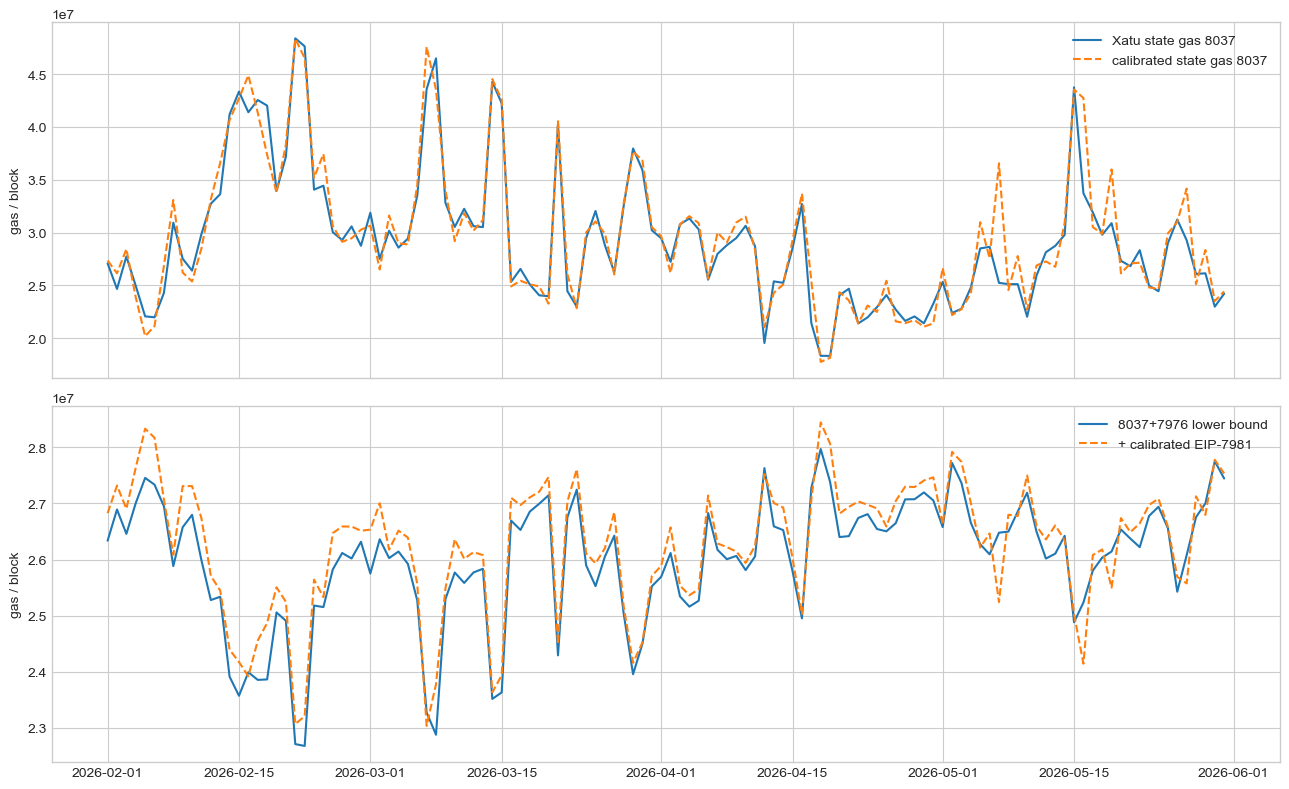

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
dates_axis = pd.to_datetime(panel_cal["date"])
axes[0].plot(dates_axis, panel_cal["state_gas_8037"] / panel_cal["block_count"], label="Xatu state gas 8037")
axes[0].plot(dates_axis, panel_cal["state_gas_8037_calibrated"] / panel_cal["block_count"], label="calibrated state gas 8037", linestyle="--")
axes[0].set_ylabel("gas / block")
axes[0].legend()
axes[1].plot(dates_axis, panel_cal["execution_gas_8037_7976_lower_bound"] / panel_cal["block_count"], label="8037+7976 lower bound")
axes[1].plot(dates_axis, panel_cal["execution_gas_8037_7976_7981_calibrated_lower_bound"] / panel_cal["block_count"], label="+ calibrated EIP-7981", linestyle="--")
axes[1].set_ylabel("gas / block")
axes[1].legend()
fig.tight_layout()
plot_path = PLOTS_DIR / f"calibration_state_access_auth_{START_DATE}_{END_DATE}.png"
fig.savefig(plot_path, dpi=160)
plot_path


## Caveats

- This notebook deliberately excludes BALs and storage-read traces.
- `execution_gas_8037_7976_7981_calibrated_lower_bound` is still a lower bound because the EIP-7976 floor uplift is computed from current receipt body gas, not exact transaction-level post-state-deaccounting gas.
- BAL calibration and regression are in notebook 1.3.
